# Aulas 04-05: Árvores de Decisão

**Inteligência Artificial · Prof. Cristiano Rodrigues**

Este notebook tem duas partes:

1. **ID3 do zero** (só com Python e um pouco de `math`): entropia, ganho de informação e construção recursiva da árvore, aplicado ao exemplo "vou jogar tênis?" visto na Aula 4.
2. **scikit-learn na prática** (Aula 5): `DecisionTreeClassifier`, a curva de overfitting em função de `max_depth`, e poda por complexidade de custo (`ccp_alpha`).

Execute as células em ordem (`Shift + Enter`). Células marcadas **Exercício** pedem para você tentar antes de rodar a próxima.


## Antes de começar: como usar este notebook

Se esta é a sua primeira vez com um Jupyter Notebook, pratique aqui antes de seguir para o resto do conteúdo.

Um notebook é uma sequência de células. Células de texto (como esta) só explicam o que vem a seguir; células de código são onde você roda Python de verdade.

1. Clique na célula de código logo abaixo.
2. Pressione `Shift + Enter` para executá-la. O resultado aparece embaixo da célula.
3. Agora edite o texto entre aspas (coloque o seu nome) e rode de novo com `Shift + Enter`. Repare que a saída muda: o notebook sempre mostra o resultado da última execução.
4. Se em algum momento aparecer um erro `NameError` dizendo que uma variável não existe, normalmente é porque alguma célula anterior ainda não foi executada. Use o menu **Kernel > Restart & Run All** para rodar tudo de novo, em ordem, do início.

A partir daqui, toda vez que aparecer em negrito **Exercício**, pare e pense (ou edite o código) antes de rodar a célula seguinte.


In [1]:
meu_nome = "ainda não editei esta célula"
print(f"Oi, {meu_nome}! Bem-vindo ao notebook das Aulas 4 e 5.")


Oi, ainda não editei esta célula! Bem-vindo ao notebook das Aulas 4 e 5.


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter


## Parte 1: ID3 do zero

### 1.1 O dataset "vou jogar tênis?"

O mesmo exemplo clássico (Quinlan/Mitchell) usado na Aula 4: 14 exemplos, 3 atributos categóricos, uma classe binária.


In [3]:
dataset = [
    {"Tempo": "Ensolarado", "Umidade": "Alta",   "Vento": "Fraco", "Jogar": "Não"},
    {"Tempo": "Ensolarado", "Umidade": "Alta",   "Vento": "Forte", "Jogar": "Não"},
    {"Tempo": "Nublado",    "Umidade": "Alta",   "Vento": "Fraco", "Jogar": "Sim"},
    {"Tempo": "Chuvoso",    "Umidade": "Alta",   "Vento": "Fraco", "Jogar": "Sim"},
    {"Tempo": "Chuvoso",    "Umidade": "Normal", "Vento": "Fraco", "Jogar": "Sim"},
    {"Tempo": "Chuvoso",    "Umidade": "Normal", "Vento": "Forte", "Jogar": "Não"},
    {"Tempo": "Nublado",    "Umidade": "Normal", "Vento": "Forte", "Jogar": "Sim"},
    {"Tempo": "Ensolarado", "Umidade": "Alta",   "Vento": "Fraco", "Jogar": "Não"},
    {"Tempo": "Ensolarado", "Umidade": "Normal", "Vento": "Fraco", "Jogar": "Sim"},
    {"Tempo": "Chuvoso",    "Umidade": "Normal", "Vento": "Fraco", "Jogar": "Sim"},
    {"Tempo": "Ensolarado", "Umidade": "Normal", "Vento": "Forte", "Jogar": "Sim"},
    {"Tempo": "Nublado",    "Umidade": "Alta",   "Vento": "Forte", "Jogar": "Sim"},
    {"Tempo": "Nublado",    "Umidade": "Normal", "Vento": "Fraco", "Jogar": "Sim"},
    {"Tempo": "Chuvoso",    "Umidade": "Alta",   "Vento": "Forte", "Jogar": "Não"},
]
ATTRIBUTES = ["Tempo", "Umidade", "Vento"]
TARGET = "Jogar"

n_sim = sum(1 for r in dataset if r[TARGET] == "Sim")
n_nao = sum(1 for r in dataset if r[TARGET] == "Não")
print(f"{len(dataset)} exemplos, {n_sim} Sim / {n_nao} Não")


14 exemplos, 9 Sim / 5 Não


### 1.2 Entropia

$$H(S) = -\sum_{i=1}^{k} p_i \log_2 p_i$$


In [4]:
def entropy(rows):
    n = len(rows)
    if n == 0:
        return 0.0
    counts = Counter(r[TARGET] for r in rows)
    return -sum((c / n) * math.log2(c / n) for c in counts.values())


print("H(S) =", round(entropy(dataset), 4))
assert abs(entropy(dataset) - 0.9403) < 1e-3


H(S) = 0.9403


### 1.3 Ganho de informação

$$IG(S, A) = H(S) - \sum_{v \,\in\, \mathrm{valores}(A)} \frac{|S_v|}{|S|}\, H(S_v)$$


In [5]:
def info_gain(rows, attribute):
    total_entropy = entropy(rows)
    n = len(rows)
    values = set(r[attribute] for r in rows)
    weighted_entropy = 0.0
    for v in values:
        subset = [r for r in rows if r[attribute] == v]
        weighted_entropy += (len(subset) / n) * entropy(subset)
    return total_entropy - weighted_entropy


for attr in ATTRIBUTES:
    print(f"IG(S, {attr}) = {info_gain(dataset, attr):.4f}")


IG(S, Tempo) = 0.2467
IG(S, Umidade) = 0.1518
IG(S, Vento) = 0.0481


**Exercício**: antes de rodar a célula abaixo, qual atributo você espera que vença no nó raiz? Compare com o resultado da Aula 4 (slide "Exemplo passo a passo: o ganho de Tempo").

In [6]:
best = max(ATTRIBUTES, key=lambda a: info_gain(dataset, a))
print("Atributo escolhido para a raiz:", best)


Atributo escolhido para a raiz: Tempo


### 1.4 Construindo a árvore (recursão)

Regras de parada: (1) todos os exemplos têm a mesma classe → vira folha; (2) não sobram atributos → folha com a classe majoritária.


In [7]:
def majority_class(rows):
    return Counter(r[TARGET] for r in rows).most_common(1)[0][0]


def build_tree(rows, attributes):
    classes = set(r[TARGET] for r in rows)
    if len(classes) == 1:
        return classes.pop()                      # folha pura
    if not attributes:
        return majority_class(rows)                 # sem atributos: maioria

    best_attr = max(attributes, key=lambda a: info_gain(rows, a))
    tree = {best_attr: {}}
    remaining = [a for a in attributes if a != best_attr]

    for v in set(r[best_attr] for r in rows):
        subset = [r for r in rows if r[best_attr] == v]
        tree[best_attr][v] = build_tree(subset, remaining)

    return tree


tree = build_tree(dataset, ATTRIBUTES)
import pprint
pprint.pprint(tree)


{'Tempo': {'Chuvoso': {'Vento': {'Forte': 'Não', 'Fraco': 'Sim'}},
           'Ensolarado': {'Umidade': {'Alta': 'Não', 'Normal': 'Sim'}},
           'Nublado': 'Sim'}}


Compare com a árvore da Aula 4: `Tempo` na raiz, `Ensolarado` dividindo por `Umidade`, `Chuvoso` dividindo por `Vento`, `Nublado` já é folha `Sim`.

In [8]:
def predict(tree, example):
    if not isinstance(tree, dict):
        return tree                                 # chegou numa folha
    attribute = next(iter(tree))
    branch = tree[attribute].get(example[attribute])
    return predict(branch, example)


acertos = sum(predict(tree, r) == r[TARGET] for r in dataset)
print(f"Acurácia no próprio conjunto de treino: {acertos}/{len(dataset)} = {acertos/len(dataset):.0%}")


Acurácia no próprio conjunto de treino: 14/14 = 100%


**Exercício**: crie um novo exemplo (`{"Tempo": "Ensolarado", "Umidade": "Normal", "Vento": "Forte"}`) e use `predict(tree, novo_exemplo)` para classificá-lo. Confere com o que a árvore do slide prevê?

In [9]:
novo_exemplo = {"Tempo": "Ensolarado", "Umidade": "Normal", "Vento": "Forte"}
print("Previsão:", predict(tree, novo_exemplo))


Previsão: Sim


---
## Parte 2: scikit-learn na prática (Aula 5)

### 2.1 Dados: breast cancer (diagnóstico)

Trocamos para um dataset maior e numérico, com 569 exemplos e 30 atributos, para ver algo que o exemplo anterior (14 exemplos) não consegue mostrar bem: overfitting de verdade.

Documentação usada nesta parte (vale a pena deixar aberta durante o laboratório):

- [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html): todos os hiperparâmetros do modelo, incluindo `max_depth` e `min_samples_leaf`.
- [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html): como dividir treino e teste.
- [Guia de árvores de decisão, seção de poda por complexidade de custo](https://scikit-learn.org/stable/modules/tree.html#minimal-cost-complexity-pruning): a teoria por trás do `ccp_alpha`.
- [`plot_tree`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html) e [`export_text`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_text.html): as duas formas de visualizar a árvore usadas abaixo.


In [10]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f"{X.shape[0]} exemplos, {X.shape[1]} atributos")
print(f"treino: {X_train.shape[0]}  teste: {X_test.shape[0]}")


569 exemplos, 30 atributos
treino: 398  teste: 171


### 2.2 Treinar uma árvore sem limites

In [11]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

print("Acurácia treino:", clf.score(X_train, y_train))
print("Acurácia teste: ", clf.score(X_test, y_test))
print("Número de nós:  ", clf.tree_.node_count)


Acurácia treino: 1.0
Acurácia teste:  0.9181286549707602
Número de nós:   31


Repare: 100% no treino, bem menos no teste, o sinal clássico de overfitting. `export_text` mostra a árvore em texto (fica enorme, e é exatamente o ponto).

In [12]:
print(export_text(clf, feature_names=list(data.feature_names), max_depth=2))


|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- smoothness error <= 0.00
|   |   |   |--- truncated branch of depth 2
|   |   |--- smoothness error >  0.00
|   |   |   |--- truncated branch of depth 4
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 23.74
|   |   |   |--- truncated branch of depth 2
|   |   |--- worst texture >  23.74
|   |   |   |--- truncated branch of depth 2
|--- worst radius >  16.80
|   |--- texture error <= 0.45
|   |   |--- class: 1
|   |--- texture error >  0.45
|   |   |--- worst concavity <= 0.19
|   |   |   |--- truncated branch of depth 2
|   |   |--- worst concavity >  0.19
|   |   |   |--- class: 0



### 2.3 A curva de overfitting: acurácia x max_depth

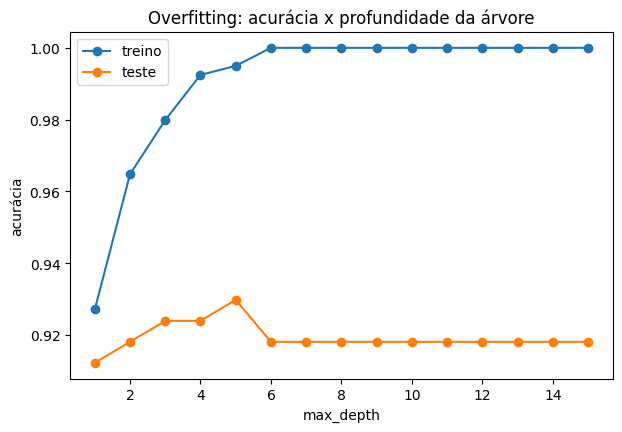

Melhor max_depth (no teste): 5 -> acurácia: 0.9298245614035088


In [13]:
depths = range(1, 16)
train_acc, test_acc = [], []
for d in depths:
    c = DecisionTreeClassifier(max_depth=d, random_state=42)
    c.fit(X_train, y_train)
    train_acc.append(c.score(X_train, y_train))
    test_acc.append(c.score(X_test, y_test))

plt.figure(figsize=(7, 4.5))
plt.plot(list(depths), train_acc, marker="o", label="treino")
plt.plot(list(depths), test_acc, marker="o", label="teste")
plt.xlabel("max_depth")
plt.ylabel("acurácia")
plt.legend()
plt.title("Overfitting: acurácia x profundidade da árvore")
plt.show()

melhor_depth = list(depths)[int(np.argmax(test_acc))]
print("Melhor max_depth (no teste):", melhor_depth, "-> acurácia:", max(test_acc))


**Exercício**: mude `random_state` do `train_test_split` para outro número e rode de novo. O melhor `max_depth` muda? Isso é evidência de por que escolher hiperparâmetros olhando só um split de teste é arriscado (assunto da Aula 7: validação cruzada).

### 2.4 Poda por complexidade de custo (ccp_alpha)

$$R_\alpha(T) = R(T) + \alpha \, |\widetilde{T}|$$


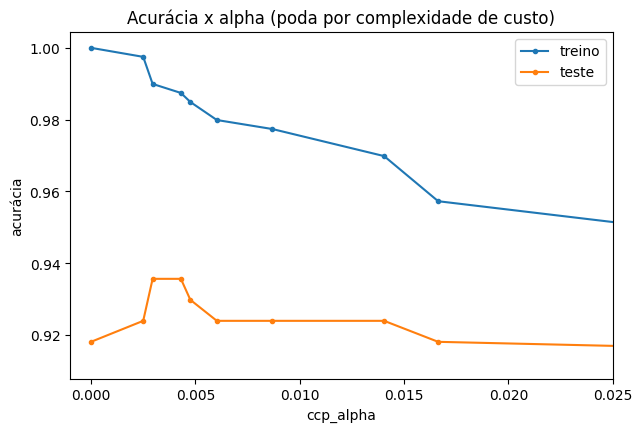

Melhor alpha ≈ 0.00295  acurácia teste = 0.9357  nós = 17
Árvore cheia (alpha=0): acurácia teste = 0.9181  nós = 31


In [14]:
arvore_cheia = DecisionTreeClassifier(random_state=42)
path = arvore_cheia.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# descarta o último alpha (poda até restar 1 nó só - não é útil aqui)
ccp_alphas = ccp_alphas[:-1]

train_acc2, test_acc2, n_nodes = [], [], []
for alpha in ccp_alphas:
    c = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    c.fit(X_train, y_train)
    train_acc2.append(c.score(X_train, y_train))
    test_acc2.append(c.score(X_test, y_test))
    n_nodes.append(c.tree_.node_count)

plt.figure(figsize=(7, 4.5))
plt.plot(ccp_alphas, train_acc2, marker="o", markersize=3, label="treino")
plt.plot(ccp_alphas, test_acc2, marker="o", markersize=3, label="teste")
plt.xlabel("ccp_alpha")
plt.ylabel("acurácia")
plt.xlim(-0.001, 0.025)
plt.legend()
plt.title("Acurácia x alpha (poda por complexidade de custo)")
plt.show()

melhor_i = int(np.argmax(test_acc2))
print(f"Melhor alpha ≈ {ccp_alphas[melhor_i]:.5f}  "
      f"acurácia teste = {test_acc2[melhor_i]:.4f}  nós = {n_nodes[melhor_i]}")
print(f"Árvore cheia (alpha=0): acurácia teste = {test_acc2[0]:.4f}  nós = {n_nodes[0]}")


### 2.5 Visualizando a árvore podada final

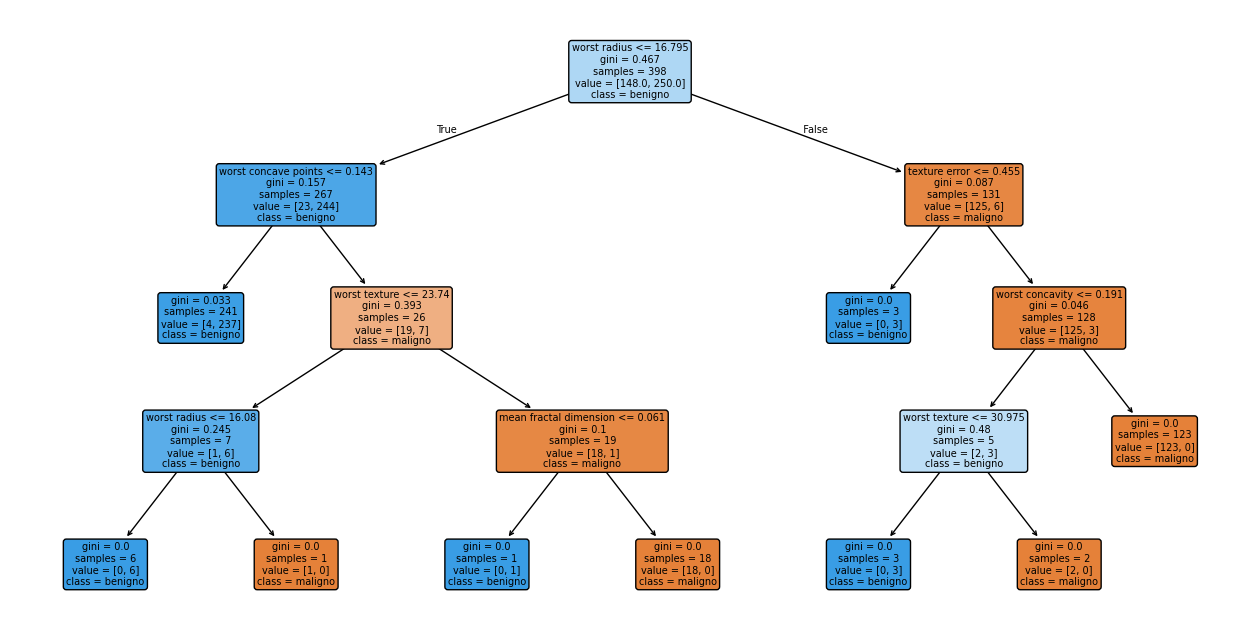

In [15]:
melhor_alpha = ccp_alphas[melhor_i]
arvore_podada = DecisionTreeClassifier(random_state=42, ccp_alpha=melhor_alpha)
arvore_podada.fit(X_train, y_train)

plt.figure(figsize=(16, 8))
plot_tree(arvore_podada, feature_names=data.feature_names,
          class_names=["maligno", "benigno"], filled=True, rounded=True, fontsize=7)
plt.show()


## Para praticar mais

Como a aula de hoje é no laboratório, a lista teórica de exercícios não vai ser entregue desta vez. As duas atividades abaixo (adaptadas do Exercício 5 da lista) ficam aqui como prática de código para o que sobrar de aula; o que não terminar, pode terminar em casa.

**a) Troque de dataset.** Troque `load_breast_cancer` por `sklearn.datasets.load_wine` ou `load_digits` e repita as seções 2.3 e 2.4 (curva de `max_depth` e poda por `ccp_alpha`). A poda ajuda tanto quanto ajudou aqui? O melhor `max_depth`/`ccp_alpha` é parecido?

**b) Troque o hiperparâmetro.** Ainda no dataset escolhido, repita a ideia da seção 2.3, mas variando `min_samples_leaf` de 1 a 20 em vez de `max_depth`. O formato da curva de overfitting é parecido? Em que ponto o modelo passa a sofrer overfitting? A definição exata de `min_samples_leaf` está na [documentação do `DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier).


**Bônus (opcional, não é obrigatório):** nos itens 2.3 e 2.4 escolhemos o melhor `max_depth`/`ccp_alpha` olhando a acurácia no conjunto de teste. Na Aula 7 vamos ver por que isso não é totalmente honesto, e como usar validação cruzada (`cross_val_score`) para escolher hiperparâmetros sem espiar o teste antes da hora. Se quiser adiantar, pesquise `cross_val_score` na documentação do scikit-learn e tente adaptar a busca por `ccp_alpha` da seção 2.4 para usar validação cruzada em vez do conjunto de teste. Documentação: [`cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html).
